<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_10_Sequential_Number_Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part_1:Token counts of numbers

## Task_1:
- Import the GPT-2 model and its tokenizer, and extract the embed
dings matrix from the model (you’ll start using the embeddings in
Part 3).In a for-loop over integers from-1000 to +1000, convert each
number to a string, tokenize, and store the token indices and the
number of tokens. Create a scatter plot of the encoded number bythe number of tokens, as in Figure 3.14.

In [23]:
from transformers import AutoTokenizer,GPT2Model
tokenizer_G = AutoTokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [24]:
embeddings=model.wte.weight.detach()

In [25]:
numbers=np.arange(-1000,1001)
num_tokens=np.zeros(len(numbers),dtype=int)
token_idx=[]

In [26]:
for i in range(len(numbers)):
  str_i=str(numbers[i])
  token_i=tokenizer_G.encode(str_i)
  token_idx.append(token_i)
  num_tokens[i]=len(token_i)


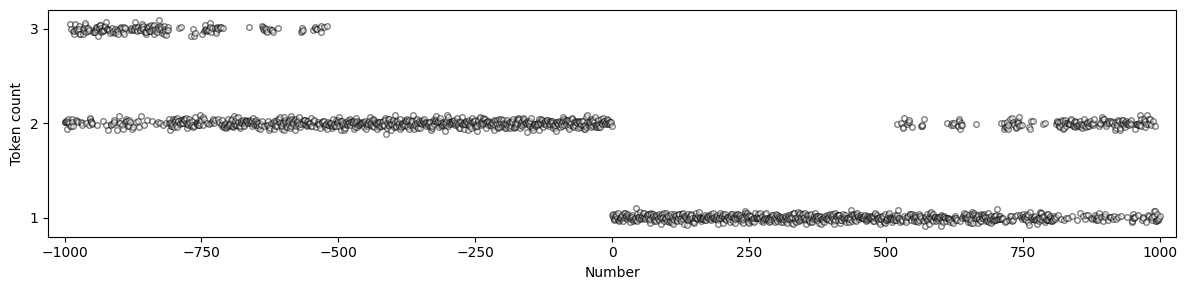

In [27]:
plt.figure(figsize=(12,3))
plt.plot(numbers,num_tokens+np.random.normal(0,.03,len(numbers)),'ko',markerfacecolor='w',markersize=4,alpha=.5)
plt.gca().set(xlabel='Number',ylabel='Token count',yticks=np.unique(num_tokens),
              xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.show()

## Task_2
- Write code to create Figure 3.15, which plots the numerical values
of the token indices. Blue circles correspond to the first token in the
number, green squares correspond to the second token in the number,
and red triangles correspond to the third token in the number.

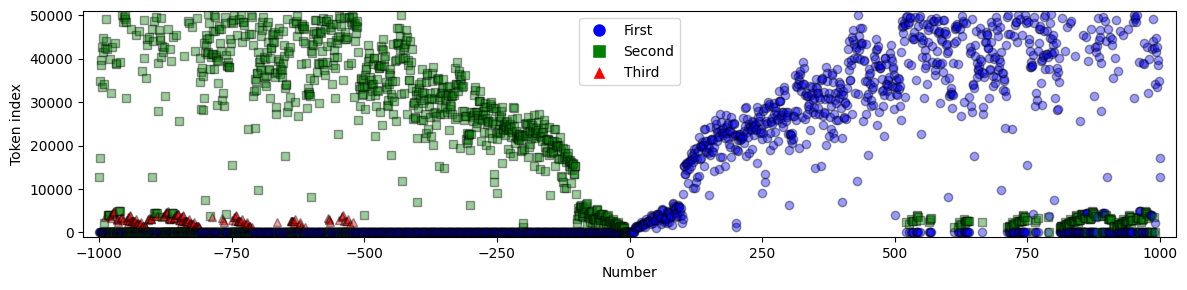

In [28]:
plt.figure(figsize=(12,3))
colord = 'bgr'
shape = 'os^'

# loop over tokens
for i in range(len(numbers)):

  # extract the token indices for this number
  t = token_idx[i]

  # plot them
  for ti in range(len(t)):
    plt.plot(numbers[i],t[ti],'k',marker=shape[ti],markerfacecolor=colord[ti],
             markersize=6,alpha=.4,linewidth=.4)


# hacky legend solution (plot with alpha=0)
for i in range(3):
  plt.plot(0,0,'w',marker=shape[i],markerfacecolor=colord[i],
             markersize=10,alpha=0,linewidth=.5,label=['First','Second','Third'][i])
h = plt.legend()
for e in h.legend_handles: e.set_alpha(1)

plt.gca().set(xlabel='Number',ylabel='Token index',ylim=[-1000,51000],xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.show()

# Part 2: Opposite sign, equal token indices

In [29]:
num_tokens

array([2, 2, 2, ..., 1, 1, 1])

## Task_1:
- Write code to test whether the token sequence of −N is the same
as the token sequence sequence of N (except for the minus sign) for
the integers used in Part 1. That is, are the tokens identical for the
strings “-543” and “543” except for an additional token to encode “-”?

In [50]:

# initialize
matches_count = np.zeros(1000)
matches_vals = np.zeros(1000)

for i in range(1000):

  # confirm the digit pairing and token count
  n = f'({numbers[i]:>5},{numbers[-i-1]:>4})'
  t = f'({num_tokens[i]-1},{num_tokens[-i-1]})'

  # see if they match
  matches_count[i] = (num_tokens[i]-1) == num_tokens[-i-1]
  matches_vals[i] = token_idx[i][1:] == token_idx[-i-1]

  # print(n,t)

matches_count.sum(), matches_vals.sum()

(np.float64(1000.0), np.float64(1000.0))

In [37]:
matches_count = []
matches_vals = np.zeros(1000)

for i in range(1, 1001):
    token_i = tokenizer_G.encode(str(i))
    token_neg = tokenizer_G.encode(str(-i))

    if len(token_neg) == len(token_i) + 1:
        if token_neg[1:] == token_i:
            matches_count.append(i)
            matches_vals[i-1] = 1

len(matches_count)

1000

# Part_3:Sucessive digit cosine similarity

## Task_1:
- Calculate pairwise cosine similarity between sequential pairs of to
kenized numbers from 0 through 10, and show the results in a bar
plot

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

In [64]:
numbers=np.arange(1,11)
tokens=[]
for n in numbers:
    print(n, tokenizer_G.encode(str(n)))
    tokens.append(tokenizer_G.encode(str(n)))


1 [16]
2 [17]
3 [18]
4 [19]
5 [20]
6 [21]
7 [22]
8 [23]
9 [24]
10 [940]


In [65]:
tokens

[[16], [17], [18], [19], [20], [21], [22], [23], [24], [940]]

In [67]:
for i in range(len(tokens)-1):
  x=tokens[i],tokens[i+1]
  print(x)

([16], [17])
([17], [18])
([18], [19])
([19], [20])
([20], [21])
([21], [22])
([22], [23])
([23], [24])
([24], [940])


In [68]:
cosim=np.full(10,np.nan)

In [71]:
for i in range(len(tokens)-1):
  v1=embeddings[tokens[i]]
  v2=embeddings[tokens[i+1]]
  sim=cosine_similarity(v1.reshape(1,-1),v2.reshape(1,-1))
  cosim[i]=sim.item()


In [72]:
cosim

array([0.82465774, 0.85154074, 0.83924913, 0.82466161, 0.83944893,
       0.83048618, 0.83118552, 0.82330787, 0.6159212 ,        nan])

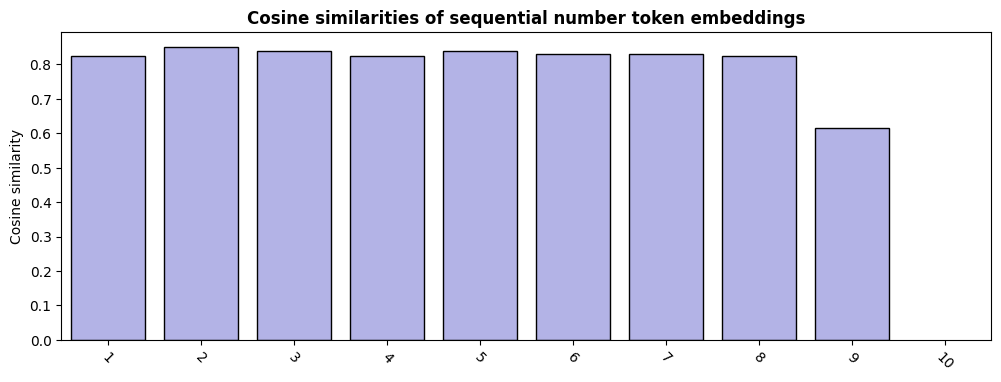

In [74]:
plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cosim)),cosim,facecolor=[.7,.7,.9],edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer_G.decode(t) for t in tokens],
              xlim=[-.5,len(tokens)-.5],ylabel='Cosine similarity')
plt.gca().tick_params(axis='x',rotation=-45)

plt.title('Cosine similarities of sequential number token embeddings',fontweight='bold')

plt.show()

In [79]:
import torch

In [76]:
for i in range(11):
  print(f'The token(s) for "{i}" are: {tokenizer_G.encode(str(i))}')

The token(s) for "0" are: [15]
The token(s) for "1" are: [16]
The token(s) for "2" are: [17]
The token(s) for "3" are: [18]
The token(s) for "4" are: [19]
The token(s) for "5" are: [20]
The token(s) for "6" are: [21]
The token(s) for "7" are: [22]
The token(s) for "8" are: [23]
The token(s) for "9" are: [24]
The token(s) for "10" are: [940]


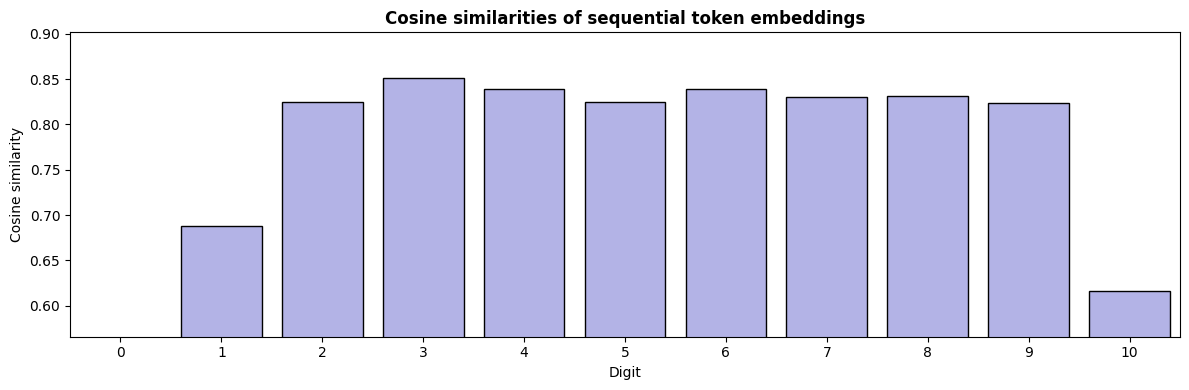

In [81]:
# tokenize the digits
tokens = [tokenizer_G.encode(str(i))[0] for i in range(11)]

# initialize cosine similarity
cossim = np.full(len(tokens),np.nan)

# calculate cosine similarity for successive digit pairs
for ti in range(1,len(tokens)):
  v1 = embeddings[tokens[ti],:]
  v2 = embeddings[tokens[ti-1],:]
  cossim[ti] = torch.sum(v1*v2) / torch.sqrt( torch.sum(v1**2)*torch.sum(v2**2) )


# plot!
plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cossim)),cossim,facecolor=[.7,.7,.9],edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer_G.decode(t) for t in tokens],
              xlabel='Digit',ylabel='Cosine similarity',
              xlim=[-.5,len(tokens)-.5],ylim=[np.nanmin(cossim)-.05,np.nanmax(cossim)+.05])

plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.show()

# Part_4:All to All Number Similarities

## Task_1:
- Confirm that the integers 0 through 10, and the integers 10, 20, 30,
..., 100 are all single-token strings.
Extract the embeddings vectors for the numbers 0, 1, ..., 10,
20, 30, ... 100 into a submatrix. Calculate the cosine similarity
matrix manually by multiplying that submatrix by its transpose
after normalization with the PyTorch function normalize, which is
in the nn.functional module. Visualize the matrix as a heatmap
as in Figure 3.17

In [82]:
nums=[str(i) for i in range(10)] +[str(i*10) for i in range(1,11)]
tokens=tokenizer_G.encode(nums)

In [86]:
print(nums,end="")
print("\n")
print(tokens,end="")

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']

[[15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [940], [1238], [1270], [1821], [1120], [1899], [2154], [1795], [3829], [3064]]

In [87]:
tokens=[t[0] for t in tokens]

In [89]:
print(tokens,end="")

[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 940, 1238, 1270, 1821, 1120, 1899, 2154, 1795, 3829, 3064]

In [90]:
for t in tokens:
  print(f'{t:5} is {tokenizer_G.decode(t)}')

   15 is 0
   16 is 1
   17 is 2
   18 is 3
   19 is 4
   20 is 5
   21 is 6
   22 is 7
   23 is 8
   24 is 9
  940 is 10
 1238 is 20
 1270 is 30
 1821 is 40
 1120 is 50
 1899 is 60
 2154 is 70
 1795 is 80
 3829 is 90
 3064 is 100


In [91]:
import torch.nn.functional as F

In [92]:
E=embeddings[tokens]
E_norm=F.normalize(E,p=2,dim=1)
csm=E_norm @ E_norm.T

In [93]:
E.shape

torch.Size([20, 768])

In [96]:
csm.shape

torch.Size([20, 20])

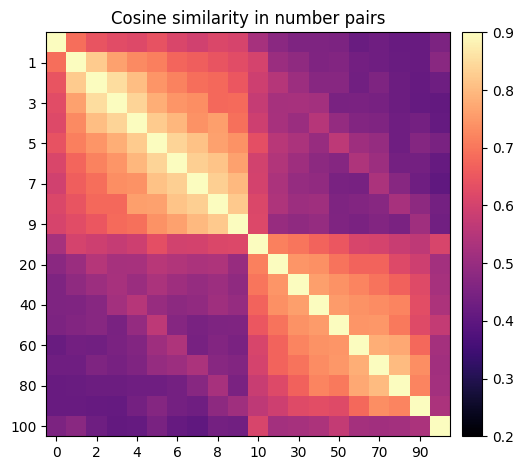

In [99]:
plt.imshow(csm,vmin=.2,vmax=.9,cmap='magma')
plt.gca().set(xticks=range(0,len(nums),2),xticklabels=nums[::2],
              yticks=range(1,len(nums),2),yticklabels=nums[1::2],
              title='Cosine similarity in number pairs')
plt.colorbar(pad=.02)

plt.tight_layout()
plt.show()

In [100]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Dummy data, same shape as your E
E = torch.randn(20, 768)

# PyTorch version
E_norm = F.normalize(E, p=2, dim=1)
csm_torch = (E_norm @ E_norm.T).numpy()

# sklearn version
csm_sklearn = cosine_similarity(E.numpy())

# Compare
print(np.allclose(csm_torch, csm_sklearn, atol=1e-6))
# True

True
